Data Preprocessing






In [1]:
#Mount drive
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')

Mounted at /content/drive
Drive mounted!


In [2]:
!pip install pretty_midi -q
print('Dependencies installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 71.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.3 MB/s eta 0:00:00
Dependencies installed!


In [4]:
#Necessary Libraries
import os
import glob
import numpy as np
import pandas as pd
import pretty_midi
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import urllib.request, zipfile, tarfile

warnings.filterwarnings('ignore')

BASE_DIR = '/content/drive/MyDrive/music_project'

# Create folder structure
folders = [
    f'{BASE_DIR}/data/maestro',
    f'{BASE_DIR}/data/lakh',
    f'{BASE_DIR}/data/processed/task1',
    f'{BASE_DIR}/data/processed/task2_3',
    f'{BASE_DIR}/outputs/generated_midis',
    f'{BASE_DIR}/outputs/plots',
    f'{BASE_DIR}/models',
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print('All imports loaded')
print('Folder structure ready')

All imports loaded
Folder structure ready


In [5]:
#Datasets downloads.If its already downloaded then skipping it

MAESTRO_DIR = f'{BASE_DIR}/data/maestro/'
LAKH_DIR    = f'{BASE_DIR}/data/lakh/'

# Checking if the datasets already downloaded
maestro_exists = len(glob.glob(f'{MAESTRO_DIR}/**/*.midi', recursive=True)) > 0
lakh_exists    = len(glob.glob(f'{LAKH_DIR}/**/*.mid',   recursive=True)) > 0

if maestro_exists:
    print('MAESTRO already downloaded')
else:
    print('Downloading MAESTRO')
    url = 'https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip'
    urllib.request.urlretrieve(url, f'{MAESTRO_DIR}/maestro.zip')
    with zipfile.ZipFile(f'{MAESTRO_DIR}/maestro.zip', 'r') as z:
        z.extractall(MAESTRO_DIR)
    print('MAESTRO downloaded!')

if lakh_exists:
    print('Lakh MIDI already downloaded')
else:
    print('Downloading Lakh MIDI')
    url = 'http://hog.ee.columbia.edu/craffel/lmd/clean_midi.tar.gz'
    urllib.request.urlretrieve(url, f'{LAKH_DIR}/lakh.tar.gz')
    with tarfile.open(f'{LAKH_DIR}/lakh.tar.gz', 'r:gz') as t:
        t.extractall(LAKH_DIR)
    print('Lakh MIDI downloaded')

MAESTRO already downloaded
Lakh MIDI already downloaded


In [7]:
# Finding MAESTRO CSV file
csv_files = glob.glob(f'{BASE_DIR}/data/maestro/**/*.csv', recursive=True)
print(f'CSV files found: {csv_files}')

CSV_PATH = csv_files[0] if csv_files else None

if CSV_PATH is None:
    print('CSV not found')
else:
    maestro_df = pd.read_csv(CSV_PATH)
    print(f'MAESTRO CSV loaded!')
    print(f'Total recordings : {len(maestro_df)}')
    print(f'Columns: {list(maestro_df.columns)}')
    print(f'Split distribution:')                #MAESTRO provides an official split column in its CSV file. so using it for spliting
    print(maestro_df['split'].value_counts().to_string())

CSV files found: ['/content/drive/MyDrive/music_project/data/maestro/maestro-v3.0.0/maestro-v3.0.0.csv']
MAESTRO CSV loaded!
Total recordings : 1276
Columns: ['canonical_composer', 'canonical_title', 'split', 'year', 'midi_filename', 'audio_filename', 'duration']
Split distribution:
split
train         962
test          177
validation    137


In [8]:
#full file paths from CSV
MAESTRO_ROOT = os.path.dirname(CSV_PATH)

def get_full_path(relative_path):
    full = os.path.join(MAESTRO_ROOT, relative_path)
    if os.path.exists(full):
        return full
    filename = os.path.basename(relative_path)
    matches  = glob.glob(f'{BASE_DIR}/data/maestro/**/{filename}', recursive=True)
    return matches[0] if matches else None

# Get files for each official split
train_files = []
val_files   = []
test_files  = []

for _, row in maestro_df.iterrows():
    path = get_full_path(row['midi_filename'])
    if path and os.path.exists(path):
        if row['split'] == 'train':
            train_files.append(path)
        elif row['split'] == 'validation':
            val_files.append(path)
        elif row['split'] == 'test':
            test_files.append(path)

print(f'Official MAESTRO split loaded')
print(f'Train files      : {len(train_files)}')
print(f'Validation files : {len(val_files)}')
print(f'Test files       : {len(test_files)}')
print(f'Total            : {len(train_files)+len(val_files)+len(test_files)}')

Official MAESTRO split loaded
Train files      : 962
Validation files : 137
Test files       : 177
Total            : 1276


In [9]:
#Exploratory Data Analysis on MAESTRO
durations   = []
note_counts = []
all_pitches = []
all_velocities = []
sample_files = train_files[:100]

for path in tqdm(sample_files):
    try:
        midi = pretty_midi.PrettyMIDI(path)
        durations.append(midi.get_end_time())
        notes = [n for inst in midi.instruments for n in inst.notes]
        note_counts.append(len(notes))
        all_pitches.extend([n.pitch    for n in notes])
        all_velocities.extend([n.velocity for n in notes])
    except:
        pass

print(f'EDA Summary:')
print(f'Files analyzed        : {len(durations)}')
print(f'Avg piece duration    : {np.mean(durations):.1f} seconds ({np.mean(durations)/60:.1f} min)')
print(f'Min/Max duration      : {min(durations):.0f}s / {max(durations):.0f}s')
print(f'Avg notes per piece   : {np.mean(note_counts):.0f}')
print(f'Avg pitch             : {np.mean(all_pitches):.1f} (middle C = 60)')
print(f'Avg velocity          : {np.mean(all_velocities):.1f}')

100%|██████████| 100/100 [01:10<00:00,  1.42it/s]

EDA Summary:
Files analyzed        : 100
Avg piece duration    : 498.2 seconds (8.3 min)
Min/Max duration      : 78s / 2463s
Avg notes per piece   : 4743
Avg pitch             : 63.9 (middle C = 60)
Avg velocity          : 63.9


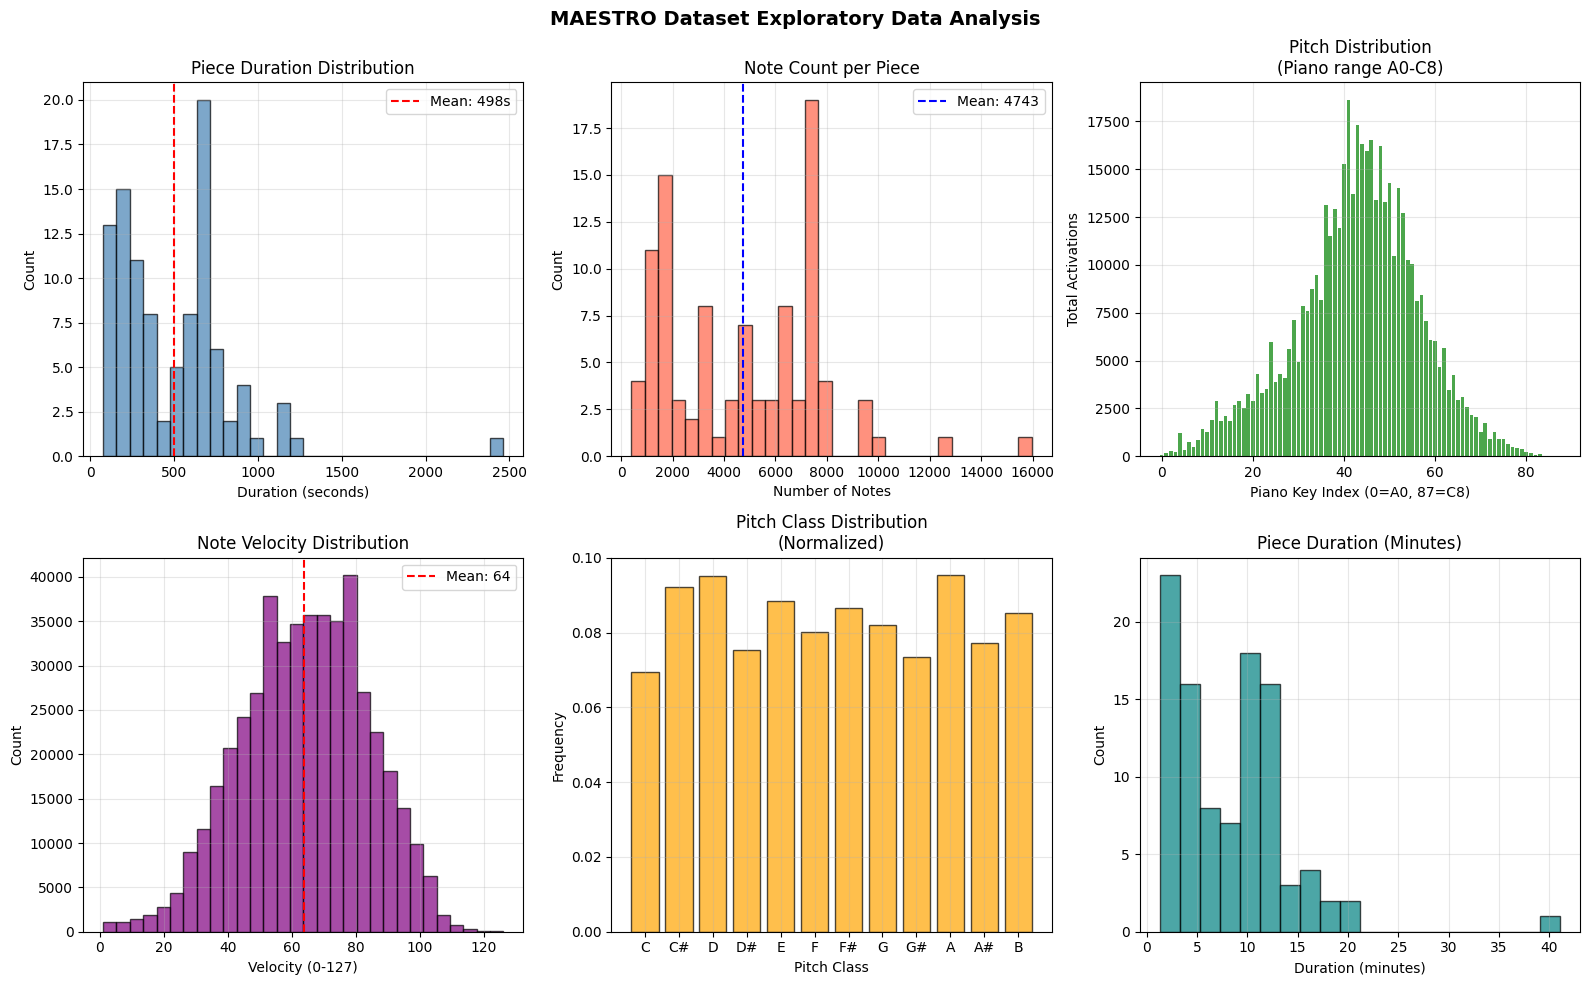

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

#Duration histogram
axes[0,0].hist(durations, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].set_title('Piece Duration Distribution')
axes[0,0].set_xlabel('Duration (seconds)')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(np.mean(durations), color='red', linestyle='--',
                   label=f'Mean: {np.mean(durations):.0f}s')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

#Note count distribution
axes[0,1].hist(note_counts, bins=30, color='tomato', edgecolor='black', alpha=0.7)
axes[0,1].set_title('Note Count per Piece')
axes[0,1].set_xlabel('Number of Notes')
axes[0,1].set_ylabel('Count')
axes[0,1].axvline(np.mean(note_counts), color='blue', linestyle='--',
                   label=f'Mean: {np.mean(note_counts):.0f}')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

#Pitch distribution (88 piano keys)
pitch_counts = np.zeros(88)
for p in all_pitches:
    if 21 <= p <= 108:
        pitch_counts[p - 21] += 1
axes[0,2].bar(range(88), pitch_counts, color='green', alpha=0.7)
axes[0,2].set_title('Pitch Distribution\n(Piano range A0-C8)')
axes[0,2].set_xlabel('Piano Key Index (0=A0, 87=C8)')
axes[0,2].set_ylabel('Total Activations')
axes[0,2].grid(True, alpha=0.3)

#Velocity distribution
axes[1,0].hist(all_velocities, bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1,0].set_title('Note Velocity Distribution')
axes[1,0].set_xlabel('Velocity (0-127)')
axes[1,0].set_ylabel('Count')
axes[1,0].axvline(np.mean(all_velocities), color='red', linestyle='--',
                   label=f'Mean: {np.mean(all_velocities):.0f}')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

#Pitch class distribution (12 classes)
pitch_classes = np.zeros(12)
note_names    = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
for p in all_pitches:
    pitch_classes[p % 12] += 1
pitch_classes = pitch_classes / pitch_classes.sum()
axes[1,1].bar(note_names, pitch_classes, color='orange', edgecolor='black', alpha=0.7)
axes[1,1].set_title('Pitch Class Distribution\n(Normalized)')
axes[1,1].set_xlabel('Pitch Class')
axes[1,1].set_ylabel('Frequency')
axes[1,1].grid(True, alpha=0.3)

#Duration in minutes histogram
durations_min = [d/60 for d in durations]
axes[1,2].hist(durations_min, bins=20, color='teal', edgecolor='black', alpha=0.7)
axes[1,2].set_title('Piece Duration (Minutes)')
axes[1,2].set_xlabel('Duration (minutes)')
axes[1,2].set_ylabel('Count')
axes[1,2].grid(True, alpha=0.3)

plt.suptitle('MAESTRO Dataset Exploratory Data Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/plots/eda_analysis.png', dpi=150)
plt.show()

In [12]:
#checking sparsity
sparsity_values = []
for path in train_files[:20]:
    try:
        midi  = pretty_midi.PrettyMIDI(path)
        pr    = midi.get_piano_roll(fs=16)
        pr    = (pr > 0).astype(np.float32)
        sparsity = 1 - (pr.sum() / pr.size)
        sparsity_values.append(sparsity)
    except:
        pass

avg_sparsity = np.mean(sparsity_values)
print(f'Sparsity Analysis:')
print(f'Average sparsity : {avg_sparsity*100:.1f}%')

Sparsity Analysis:
Average sparsity : 94.7%


In [15]:
#Fucntion for Piano Roll Preprocessing
def midi_to_piano_roll(midi_path, fs=16):
    try:
        midi       = pretty_midi.PrettyMIDI(midi_path)
        piano_roll = midi.get_piano_roll(fs=fs)
        piano_roll = (piano_roll > 0).astype(np.float32)
        piano_roll = piano_roll[21:109, :]
        return piano_roll
    except:
        return None


def segment_piano_roll(piano_roll, window_size=128):
    T        = piano_roll.shape[1]
    segments = []
    for start in range(0, T - window_size + 1, window_size):
        seg         = piano_roll[:, start:start + window_size]  # (88, window_size)
        total_cells = seg.shape[0] * seg.shape[1]
        active      = seg.sum()
        if active / total_cells >= 0.02:  # Filter: keep only windows with >= 2% active cells
            segments.append(seg)
    return np.array(segments) if segments else None


WINDOW_SIZE = 128
print('Preprocessing functions defined!')
print(f'Window size : {WINDOW_SIZE} time steps = {WINDOW_SIZE/16:.0f} seconds')

Preprocessing functions defined!
Window size : 128 time steps = 8 seconds


In [16]:
#MAESTRO train split (Classical) for task 1

MAX_TRAIN = 200
MAX_VAL   = 50
MAX_TEST  = 50

def process_files(file_list, max_files, label):
    all_segments = []
    print(f'Processing {label} ({min(len(file_list), max_files)} files)')
    for path in tqdm(file_list[:max_files]):
        pr   = midi_to_piano_roll(path)
        if pr is None:
            continue
        segs = segment_piano_roll(pr, WINDOW_SIZE)
        if segs is not None:
            all_segments.append(segs)
    if not all_segments:
        return np.array([])
    return np.concatenate(all_segments, axis=0)

#split
maestro_train = process_files(train_files, MAX_TRAIN, 'MAESTRO Train')
maestro_val   = process_files(val_files,   MAX_VAL,   'MAESTRO Validation')
maestro_test  = process_files(test_files,  MAX_TEST,  'MAESTRO Test')

print(f'MAESTRO processing complete!')
print(f'Train segments : {len(maestro_train)}')
print(f'Val   segments : {len(maestro_val)}')
print(f'Test  segments : {len(maestro_test)}')

Processing MAESTRO Train (200 files)


100%|██████████| 200/200 [01:40<00:00,  2.00it/s]


Processing MAESTRO Validation (50 files)


100%|██████████| 50/50 [00:30<00:00,  1.67it/s]


Processing MAESTRO Test (50 files)


100%|██████████| 50/50 [00:28<00:00,  1.77it/s]

MAESTRO processing complete!
Train segments : 12596
Val   segments : 2294
Test  segments : 1914


In [17]:
#Lakh MIDI (multi genre) random split for task 2 and 3
LAKH_DIR   = f'{BASE_DIR}/data/lakh/'
lakh_files = glob.glob(f'{LAKH_DIR}/**/*.mid', recursive=True)
print(f'Lakh MIDI files found: {len(lakh_files)}')

MAX_LAKH = 500
lakh_segments = []

print(f'Processing Lakh MIDI (up to {MAX_LAKH} files)')
for path in tqdm(lakh_files[:MAX_LAKH]):
    pr   = midi_to_piano_roll(path)
    if pr is None:
        continue
    segs = segment_piano_roll(pr, WINDOW_SIZE)
    if segs is not None:
        lakh_segments.append(segs)

lakh_data = np.concatenate(lakh_segments, axis=0) if lakh_segments else np.array([])
print(f'Lakh segments: {len(lakh_data)}')

Lakh MIDI files found: 18884
Processing Lakh MIDI (up to 500 files)


100%|██████████| 500/500 [04:54<00:00,  1.70it/s]


Lakh segments: 12924


In [18]:
# Final datasets

task1_train = maestro_train
task1_val   = maestro_val
task1_test  = maestro_test

print('Task 1 (MAESTRO — official split):')
print(f'Train : {task1_train.shape}')
print(f'Val   : {task1_val.shape}')
print(f'Test  : {task1_test.shape}')

if len(lakh_data) > 0:
    lakh_train_temp, lakh_test = train_test_split(lakh_data, test_size=0.1, random_state=42)
    lakh_train, lakh_val       = train_test_split(lakh_train_temp, test_size=0.111, random_state=42)
else:
    lakh_train = lakh_val = lakh_test = np.array([])

# Combine MAESTRO + Lakh for task 2 and 3
def safe_concat(a, b):
    if len(a) > 0 and len(b) > 0:
        return np.concatenate([a, b], axis=0)
    return a if len(a) > 0 else b

task23_train = safe_concat(maestro_train, lakh_train)
task23_val   = safe_concat(maestro_val,   lakh_val)
task23_test  = safe_concat(maestro_test,  lakh_test)

print('Task 2/3 (MAESTRO + Lakh combined):')
print(f'Train : {task23_train.shape}')
print(f'Val   : {task23_val.shape}')
print(f'Test  : {task23_test.shape}')

Task 1 (MAESTRO — official split):
Train : (12596, 88, 128)
Val   : (2294, 88, 128)
Test  : (1914, 88, 128)
Task 2/3 (MAESTRO + Lakh combined):
Train : (22935, 88, 128)
Val   : (3586, 88, 128)
Test  : (3207, 88, 128)


In [20]:
#Saving splits for Task 1
np.save(f'{BASE_DIR}/data/processed/task1/X_train.npy', task1_train)
np.save(f'{BASE_DIR}/data/processed/task1/X_val.npy',   task1_val)
np.save(f'{BASE_DIR}/data/processed/task1/X_test.npy',  task1_test)

# Saving splits for Task 2/3
np.save(f'{BASE_DIR}/data/processed/task2_3/X_train.npy', task23_train)
np.save(f'{BASE_DIR}/data/processed/task2_3/X_val.npy',   task23_val)
np.save(f'{BASE_DIR}/data/processed/task2_3/X_test.npy',  task23_test)

print('All splits saved')

All splits saved


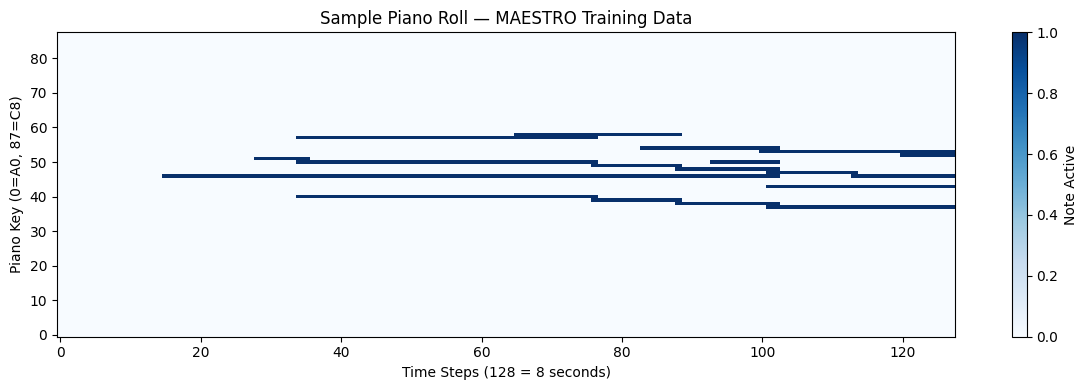

In [21]:
#Visualize Sample Piano Roll
sample = task1_train[0]

plt.figure(figsize=(12, 4))
plt.imshow(sample, aspect='auto', origin='lower', cmap='Blues')
plt.xlabel('Time Steps (128 = 8 seconds)')
plt.ylabel('Piano Key (0=A0, 87=C8)')
plt.title('Sample Piano Roll — MAESTRO Training Data')
plt.colorbar(label='Note Active')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/plots/sample_piano_roll.png', dpi=150)
plt.show()

In [23]:
#Summary all things that have been done

print(f'Split method     : MAESTRO=Official CSV | Lakh=Random 80/10/10')
print(f'Piano range      : 88 keys (MIDI 21-108)')
print(f'Window size      : 128 time steps = 8 seconds')
print(f'Sparsity filter  : >= 2% active cells per window')
print(f'EDA plots        : Saved to outputs/plots/')

Split method     : MAESTRO=Official CSV | Lakh=Random 80/10/10
Piano range      : 88 keys (MIDI 21-108)
Window size      : 128 time steps = 8 seconds
Sparsity filter  : >= 2% active cells per window
EDA plots        : Saved to outputs/plots/
